<a href="https://colab.research.google.com/github/Suvidhya1/CogniTriage/blob/main/Alzheimer's_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<b>EDA</b> (Exploratory Data Analysis on Alzheimer's Dataset)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/ADNIMERGE_21Aug2026.csv",low_memory=False)
data.shape

(16421, 116)

#EDA Step 1

In [ ]:
data.head()

,RID,COLPROT,ORIGPROT,PTID,SITE,VISCODE,EXAMDATE,DX_bl,AGE,PTGENDER,...,PTAU_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M,update_stamp
0,2,ADNI1,ADNI1,011_S_0002,11,bl,2005-09-08,CN,74.3,Male,...,NaN,1.33615,NaN,NaN,NaN,0.000000,0.00000,0,0,2023-07-07 04:59:40
1,3,ADNI1,ADNI1,011_S_0003,11,bl,2005-09-12,AD,81.3,Male,...,22.83,1.10860,NaN,NaN,NaN,0.000000,0.00000,0,0,2023-07-07 04:59:40
2,3,ADNI1,ADNI1,011_S_0003,11,m06,2006-03-13,AD,81.3,Male,...,22.83,1.10860,NaN,NaN,NaN,0.498289,5.96721,6,6,2023-07-07 04:59:40
3,3,ADNI1,ADNI1,011_S_0003,11,m12,2006-09-12,AD,81.3,Male,...,22.83,1.10860,NaN,NaN,NaN,0.999316,11.96720,12,12,2023-07-07 04:59:40
4,3,ADNI1,ADNI1,011_S_0003,11,m24,2007-09-12,AD,81.3,Male,...,22.83,1.10860,NaN,NaN,NaN,1.998630,23.93440,24,24,2023-07-07 04:59:40


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16421 entries, 0 to 16420
Columns: 116 entries, RID to update_stamp
dtypes: float64(88), int64(5), object(23)
memory usage: 14.5+ MB


In [ ]:
data.describe()

,RID,SITE,AGE,PTEDUCAT,APOE4,FDG,PIB,AV45,FBB,CDRSB,...,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M
count,16421.000000,16421.000000,16412.000000,16421.000000,16056.000000,3693.000000,223.000000,3080.000000,513.000000,11747.000000,...,8915.000000,9085.000000,11220.000000,154.000000,7836.000000,1099.000000,16421.000000,16421.000000,16421.000000,16421.000000
mean,2899.082273,81.733329,73.214173,16.105779,0.516193,1.175624,1.783161,1.193030,1.175212,2.047927,...,1.735025,1.601863,1.226786,1.582256,1.186525,1.163109,2.738280,32.792027,32.712259,32.580903
std,2220.442824,132.762777,7.028099,2.762672,0.646953,0.167288,0.422511,0.230866,0.246133,2.866563,...,0.861453,0.670951,0.153364,0.302114,0.220110,0.236850,2.939675,35.203809,35.193789,35.124178
min,2.000000,2.000000,50.400000,4.000000,0.000000,0.566989,1.095000,0.809000,0.870200,0.000000,...,1.000000,1.000000,0.621933,1.155000,0.810000,0.870200,0.000000,0.000000,0.000000,0.000000
25%,751.000000,22.000000,68.500000,14.000000,0.000000,1.071700,1.361250,1.010075,0.996900,0.000000,...,1.000000,1.102560,1.134820,1.360000,1.012400,0.995100,0.506502,6.065570,6.000000,6.000000
50%,2308.000000,41.000000,73.200000,16.000000,0.000000,1.180590,1.850000,1.106800,1.054000,1.000000,...,1.500000,1.333330,1.234580,1.490000,1.098400,1.041700,1.960300,23.475400,24.000000,24.000000
75%,4707.000000,123.000000,78.100000,18.000000,1.000000,1.287080,2.127500,1.358425,1.350800,3.000000,...,2.000000,1.897440,1.331470,1.835000,1.346900,1.318600,4.010950,48.032800,48.000000,48.000000
max,7125.000000,941.000000,91.400000,20.000000,2.000000,1.776170,2.927500,2.686600,2.008800,18.000000,...,4.000000,3.948720,1.776170,2.282500,2.010100,1.909000,16.961000,203.115000,204.000000,204.000000


###<i>Checking for duplicate patients<br></i>From this we can infer that there are total 2430 unique patients<br> And there are multiple visits by the same patient

In [ ]:
print("Total Rows:",len(data))
print("Total unique patients:",data['RID'].nunique())

Total Rows: 16421
Total unique patients: 2430


In [ ]:
print(data['VISCODE'].value_counts().head())

# The dataset is Longitudinal

VISCODE
bl     2430
m12    1970
m06    1618
m24    1596
m18    1320
Name: count, dtype: int64


In [ ]:
# Baseline diagnosis
print(data["DX_bl"].value_counts(dropna=False))

DX_bl
LMCI    5275
CN      4904
EMCI    2995
AD      1751
SMC     1485
NaN       11
Name: count, dtype: int64


####Plotting the required data

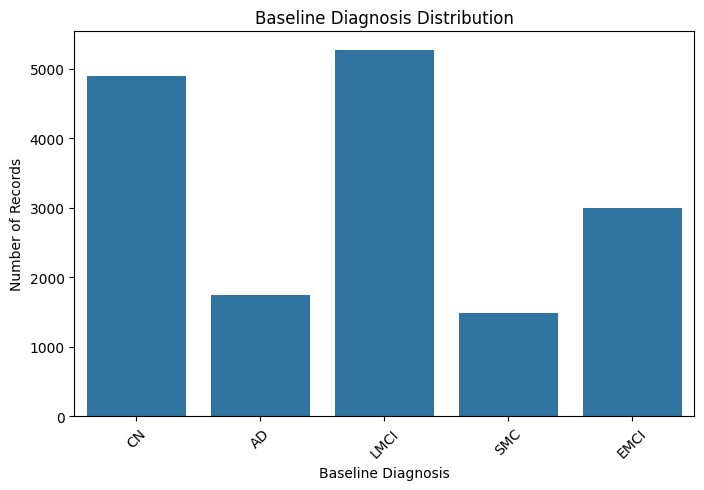

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=data,x='DX_bl')
plt.title("Baseline Diagnosis Distribution")
plt.xlabel("Baseline Diagnosis")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(data['DX'].value_counts(dropna=False))

DX
MCI         4989
NaN         4963
CN          4020
Dementia    2449
Name: count, dtype: int64


#<b>Missing Value Analysis

In [ ]:
missing=data.isnull().mean()*100
missing.sort_values(ascending=False).head(30)

# Percentage of missing values in each column in descending order

,0
PIB_bl,99.062176
PIB,98.641983
FBB,96.875952
FBB_bl,93.307350
PTAU,85.573351
ABETA,85.567261
TAU,85.567261
AV45,81.243530
FDG,77.510505
DIGITSCOR,76.858900


####Plotting top 20 missing values

In [ ]:
missing_top=missing.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
missing_top.plot(kind='barh')
plt.title("Top 20 Missing Values")
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Features')

plt.show()

##<b>Required Candidate Features

In [ ]:
candidate_features=["AGE","PTGENDER","PTEDUCAT","MMSE","MOCA","CDRSB","ADAS11","ADAS13",
                    "RAVLT_immediate","RAVLT_learning","RAVLT_forgetting","RAVLT_perc_forgetting","FAQ",
                    "ABETA","TAU","PTAU",
                    "Hippocampus","WholeBrain","Ventricles","Entorhinal","Fusiform","MidTemp","ICV"]

data[candidate_features].info()

In [ ]:
data[candidate_features].isnull().mean()*100

#<B>EDA Step 2<br>
###Patient level Cohort Analysis

In [ ]:
baseline=data[data['VISCODE']=='bl'].copy()
baseline['DX_bl'].value_counts(dropna=False)

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=baseline,x='DX_bl',order=['CN','SMC','EMCI','LMCI','AD'])

plt.title("Baseline Diagnosis Distribution")
plt.xlabel("Baseline Diagnosis")
plt.ylabel("Number of Patients")

plt.show()

###Categorizing based on the visits

In [ ]:
visits_per_patient=data.groupby('RID').size()
print(visits_per_patient.head())
visits_per_patient.describe()

In [ ]:
print("Patients with only 1 visit:",(visits_per_patient==1).sum())
print("Patients with 2+ visits:",(visits_per_patient>1).sum())

NameError: name 'visits_per_patient' is not defined

###Patients Final Diagnosis(Available)

In [ ]:
data['EXAMDATE']=pd.to_datetime(data['EXAMDATE'],errors='coerce')

data_sorted=data.sort_values(['RID','EXAMDATE'])

In [ ]:
data_sorted[['RID','EXAMDATE']].head()

first_visit=data_sorted.groupby('RID').first()
last_visit=data_sorted.groupby('RID').last()

NameError: name 'data_sorted' is not defined

In [ ]:
first_visit['DX_bl'].value_counts(dropna=False)

In [ ]:
last_visit['DX'].value_counts(dropna=False)

NameError: name 'last_visit' is not defined

In [ ]:
transition_table=pd.crosstab(
    first_visit['DX_bl'],
    last_visit['DX'],
    margins=False
)
transition_table


#<b>Conclusions:</b><br>
1. i) There are 2403 unique participants<br>ii) 16421 longitudinal observations<br>
2. 2209/2403 patients have >=2 visits<br>
3. i) 2008 patients started without baseline Dimentia<br>ii) 409 eventually had recorded Dementia  

#<b>EDA Step 3 (Step 3A)<br>
###Progression Analysis - Finding the required target

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(transition_table,annot=True,fmt='d',cmap='Blues')

plt.title("Baseline Diagnosis to Final Diagnosis")
plt.xlabel("Final Diagnosis")
plt.ylabel("Baseline Diagnosis")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
non_ad=first_visit[first_visit['DX_bl']!='AD']
ad=first_visit[first_visit['DX_bl']=='AD']

print('Non-AD baseline patients:',len(non_ad))
print('AD baseline patients:',len(ad))

progressed=non_ad['DX'].eq('Dementia') #returns a boolean series

print('Eventually recorded Dementia:',progressed.sum())
print('Did not end in Dementia:',(~progressed).sum())

NameError: name 'first_visit' is not defined

In [ ]:
progression_data=data_sorted[(data_sorted['DX']=='Dementia')].groupby('RID').first()

progression_data['progression_date']=progression_data['EXAMDATE']

NameError: name 'data_sorted' is not defined

In [ ]:
progression_data['progression_date']

,progression_date
RID,
3,2005-09-12
7,2005-10-06
10,2005-11-10
29,2005-10-31
30,2006-04-13
...,...
7003,2021-10-13
7033,2022-02-01
7039,2022-03-10


#<b>EDA Step 3B</b><br>Time ro Progression analysis

In [ ]:
baseline=data_sorted.groupby('RID',as_index=False).first()
baseline_dates=baseline[['RID','EXAMDATE','DX_bl']].rename(columns={'EXAMDATE':'baseline_date'})

baseline_dates.head()

,RID,baseline_date,DX_bl
0,2,2005-09-08,CN
1,3,2005-09-12,AD
2,4,2005-11-08,LMCI
3,5,2005-09-07,CN
4,6,2005-11-29,LMCI


In [ ]:
dementia_rows=data_sorted[data_sorted['DX']=='Dementia']

dementia_dates=dementia_rows.groupby('RID',as_index=False)['EXAMDATE'].min()
dementia_dates=dementia_dates.rename(columns={'EXAMDATE':'dementia_date'})

dementia_dates.head()

,RID,dementia_date
0,3,2005-09-12
1,7,2005-10-06
2,10,2005-11-10
3,29,2005-10-31
4,30,2006-04-13


In [ ]:
progression=baseline_dates.merge(dementia_dates,on='RID',how='inner')

progression=progression[progression['DX_bl']!='AD'].copy()

In [ ]:
progression['time_to_dementia(days)']=(progression['dementia_date']-progression['baseline_date']).dt.days
progression['time_to_dementia(years)']=progression['time_to_dementia(days)']/365.25

progression.sample(10)

,RID,baseline_date,DX_bl,dementia_date,time_to_dementia(days),time_to_dementia(years)
521,4363,2011-12-12,LMCI,2014-12-18,1102,3.017112
633,4888,2012-08-22,LMCI,2013-02-14,176,0.481862
164,588,2006-12-19,LMCI,2011-08-05,1690,4.626968
556,4582,2012-03-26,LMCI,2016-06-06,1533,4.197125
378,1268,2007-03-07,LMCI,2013-03-14,2199,6.020534
591,4721,2012-05-22,LMCI,2018-11-01,2354,6.444901
626,4862,2013-08-26,LMCI,2019-09-10,2206,6.039699
493,4203,2011-09-15,LMCI,2012-09-26,377,1.032170
387,1295,2007-02-27,LMCI,2008-08-20,540,1.478439
435,2130,2011-01-19,EMCI,2015-01-29,1471,4.027379


In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(progression['time_to_dementia(years)'],bins=20)

plt.xlabel("Years from Baseline to First Recorded Dementia")
plt.ylabel("Number of Patients")
plt.title("Time to Dementia Progression")

plt.show()

NameError: name 'progression' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
progression['time_to_dementia(years)'].describe()

NameError: name 'progression' is not defined

In [ ]:
progression[progression['time_to_dementia(years)']<=0.1].shape

NameError: name 'progression' is not defined

#<b>Conclusion:</b></h1>
1. 423 non-AD baseline patients later recorded with dementia diagnosis<br>
2. Mean time to dementia-<b>3.03 years</b><br>
3. i) Min- 0 years<br>ii) Max- 13.05 years<br>

###Progression is concentrated in first few years after baseline

#<b>EDA Step 3C</b><br>Progression within different time windows

In [ ]:
for years in [1,3,5]:
  count=(progression['time_to_dementia(years)']<=years).sum()
  percentage=count/len(progression)*100

  print(f'Within {years} years: {count} patients ({percentage:.1f}%)')

NameError: name 'progression' is not defined

#<b>EDA Step 3D</b><br>Follow-up/censoring analysis

In [ ]:
# Last available examination date for each patient
last_dates=data_sorted.groupby('RID')['EXAMDATE'].max().rename('last_date')

followup=baseline_dates.merge(last_dates,on='RID',how='left')
followup['followup_years']=(followup['last_date']-followup['baseline_date']).dt.days/365.25

followup.describe()

NameError: name 'data_sorted' is not defined

In [ ]:
for years in [1,3,5]:
  count=(followup['followup_years']>=years).sum()
  percentage=count/len(followup)*100

  print(f'At least {years} years: {count} patients ({percentage:.1f}%)')

NameError: name 'followup' is not defined

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(followup['followup_years'].dropna(),bins=25)

plt.xlabel("Follow-up Duration (Years)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Patient Follow-up Duration")

plt.show()

NameError: name 'followup' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
three_year_cohort=followup[followup['followup_years']>=3].copy()
three_year_cohort['DX_bl'].value_counts(dropna=False)

NameError: name 'followup' is not defined

In [ ]:
three_year_cohort['DX_bl'].value_counts(normalize=True)*100

NameError: name 'three_year_cohort' is not defined

#<b>Conclusion:</b></h1>
####1. Median time to recorded Demetia= 2 years<br>2. 63.1% of eventual progressors reached recorded Dementia within 3 years<br>4. 1294 patients(53.3%) have >= 3 years of follow-up<br>5. 3 years gives us substantially more suitable longitudinal data than 5 years<br>

###Therefore 3 years is a strong candidate for our prediction horizon

#<b>Feature EDA Step 4</b><br>Clinical+Demographic EDA

In [ ]:
clinical_features=['AGE','PTGENDER','PTEDUCAT']

NameError: name 'data' is not defined

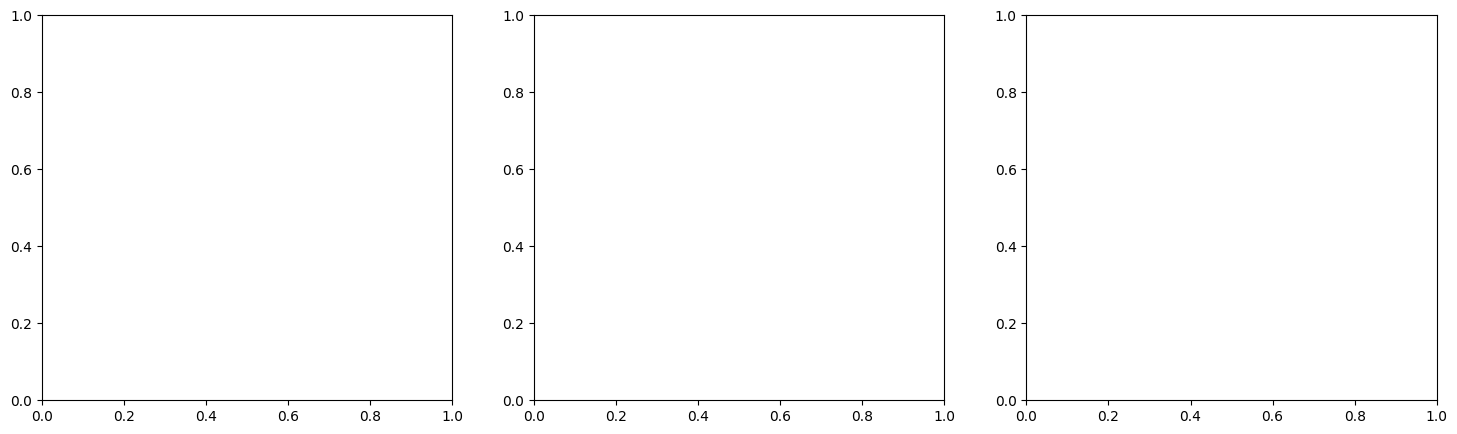

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,5))

#Age
sns.histplot(data=data,x='AGE',bins=25,ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Patients")

#Gender
sns.countplot(data=data,x='PTGENDER',ax=axes[1])
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Patients")

#Education
sns.histplot(data=data,x='PTEDUCAT',bins=20,ax=axes[2])
axes[2].set_title("Education Distribution")
axes[2].set_xlabel("Years of Education")
axes[2].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [ ]:
print("AGE")
print(data["AGE"].describe())

print("\nGENDER")
print(data["PTGENDER"].value_counts(dropna=False))

print("\nEDUCATION")
print(data["PTEDUCAT"].describe())

#<b>Step 4B</b><br>Cognitive

In [ ]:
cognitive_features=['MMSE','MOCA','CDRSB','ADAS11','ADAS13']
data[cognitive_features].describe().T

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(18,10))

for ax,feature in zip(axes.flat,cognitive_features):
  sns.histplot(data=data,x=feature,bins=25,ax=ax)
  ax.set_title(f"{feature} Distribution")
  ax.set_xlabel(feature)
  ax.set_ylabel('Count')

axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
ravlt_columns=[
    col for col in data.columns
    if 'RAVLT' in col.upper()
]
print(ravlt_columns)
print('number of ravlt columns:',len(ravlt_columns))

In [ ]:
for i,col in enumerate(ravlt_columns,1):
  print(i,col)

In [ ]:
ravlt_features=ravlt_columns
data[ravlt_features].describe().T

In [ ]:
print("\nMissing values:")
print(data[ravlt_features].isna().sum())

print("\nMissing percentage:")
print((data[ravlt_features].isna().mean() * 100).round(2))

##Conclusion<br></h2><h4>RAVLT baseline variables have very low missingness (<0.5%), whereas visit-level RAVLT variables have approximately 31% missingness. Therefore, baseline RAVLT variables are strong candidates for baseline feature analysis and modeling.

NameError: name 'data' is not defined

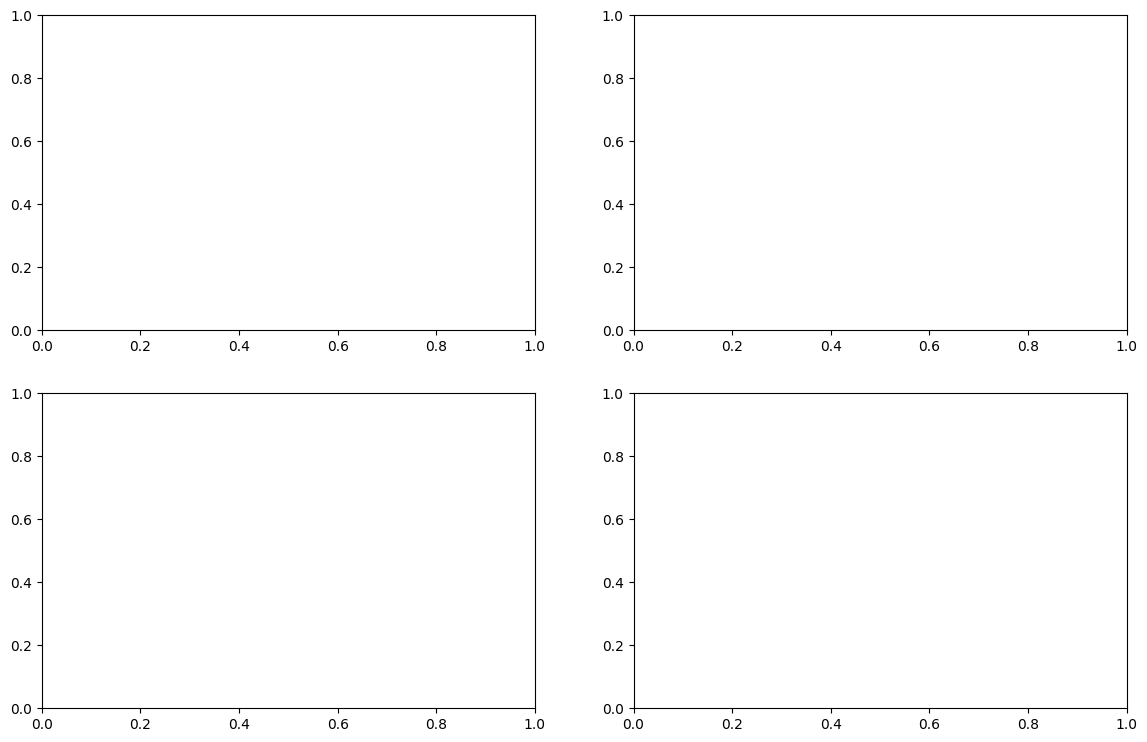

In [ ]:
ravlt_baseline = [
    "RAVLT_immediate_bl",
    "RAVLT_learning_bl",
    "RAVLT_forgetting_bl",
    "RAVLT_perc_forgetting_bl"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, feature in zip(axes.flat, ravlt_baseline):
    sns.histplot(
        data[feature].dropna(),
        bins=25,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
for feature in ravlt_baseline:
    #print(f"\n{'='*50}")
    print(feature)

    print("\nMinimum 10 values:")
    print(data[feature].nsmallest(10).to_list())

    print("\nMaximum 10 values:")
    print(data[feature].nlargest(10).to_list())

In [ ]:
for feature in ravlt_baseline:
    print(f"\n{feature}")

    if "perc_forgetting" in feature:
        print("Values < 0:", (data[feature] < 0).sum())
        print("Values > 100:", (data[feature] > 100).sum())
    else:
        print("Values < 0:", (data[feature] < 0).sum())

#<b>Step 4D</b> (Biomaker EDA)

In [ ]:
biomarker_keywords=['ABETA','TAU','PTAU','AMYLOID','BIOMARKER']

biomarker_columns=[
    col for col in data.columns
    if any(keyword in col.upper() for keyword in biomarker_keywords)
]

for i,col in enumerate(biomarker_columns,1):
  print(i,col)

print('Total biomarker related columns:',len(biomarker_columns))

In [ ]:
biomarker_baseline=['ABETA_bl','TAU_bl','PTAU_bl']

print('\nMissing values:\n',data[biomarker_baseline].isna().sum())
print('\nMissing percentage:\n',data[biomarker_baseline].isna().mean()*100)

data[biomarker_baseline].describe().T

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,5))

for ax,feature in zip(axes,biomarker_baseline):
  sns.histplot(data[feature].dropna(),bins=30,ax=ax)
  ax.set_title(f'{feature}, Distribution')
  ax.set_xlabel(feature)
  ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
for feature in biomarker_baseline:
  print(f'\n{feature}')
  print('Data type:',data[feature].dtype)
  print('Sample values:')
  print(data[feature].dropna().head(10).to_list())

In [ ]:
for feature in biomarker_baseline:
  print(f'\n{feature}')
  print(data[feature].dropna().astype(str).str.strip().value_counts().head(10))

In [ ]:
biomarker_eda=data[biomarker_baseline].copy()

biomarker_eda['TAU_bl']=pd.to_numeric(biomarker_eda['TAU_bl'],errors='coerce')
biomarker_eda['PTAU_bl']=pd.to_numeric(biomarker_eda['PTAU_bl'],errors='coerce')
biomarker_eda['ABETA_bl_censored']=(biomarker_eda['ABETA_bl'].astype(str).str.replace('>1700','1700',regex=False))
biomarker_eda['ABETA_bl_censored']=pd.to_numeric(biomarker_eda['ABETA_bl_censored'],errors='coerce')

biomarker_eda.describe().T

NameError: name 'data' is not defined

In [ ]:
plot_features = [
    "ABETA_bl_censored",
    "TAU_bl",
    "PTAU_bl"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, plot_features):
    sns.histplot(
        biomarker_eda[feature].dropna(),
        bins=30,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
abeta_censored = (
    data["ABETA_bl"]
    .astype(str)
    .str.strip()
    .eq(">1700")
)

print("ABETA >1700:", abeta_censored.sum())

print(
    "Percentage among available ABETA:",
    round(
        abeta_censored.sum() /
        data["ABETA_bl"].notna().sum() * 100,
        2
    ),
    "%"
)

#<b>Conslusion:</b></h1><h4>
1. ABETA: substantial upper-censoring (>1700, 18.68% of available values).
2. TAU: right-skewed distribution with a long high-value tail.
3. PTAU: right-skewed distribution with a high-value tail.
4. Missingness: ~38.6% for all three baseline biomarkers.

#<b>Step 4E</b><br>MRI EDA

In [ ]:
mri_keywords = [
    'MRI', 'VOLUME', 'VOL', 'THICKNESS',
    'HIPPOCAMP', 'CORTEX', 'VENTRICLE',
    'WHOLEBRAIN', 'BRAIN'
]

mri_columns = [
    col for col in data.columns
    if any(keyword in col.upper() for keyword in mri_keywords)
]

for i, col in enumerate(mri_columns, 1):
    print(i, col)

print("\nTotal MRI-related columns:", len(mri_columns))

NameError: name 'data' is not defined

In [ ]:
mri_check = [
    'Entorhinal',
    'Fusiform',
    'Midtemp',
    'ICV'
]

for feature in mri_check:
    matches = [col for col in data.columns
               if feature.upper() in col.upper()]

    print(f"\n{feature}:")
    print(matches)

NameError: name 'data' is not defined

In [ ]:
mri_features=['Hippocampus_bl','Ventricles_bl','WholeBrain_bl','Entorhinal_bl','Fusiform_bl','MidTemp_bl','ICV_bl']
data[mri_features].head()

NameError: name 'data' is not defined

In [ ]:
print("MRI Data Types:\n")
print(data[mri_features].dtypes)

print('\n\nMissing values:\n')
print(data[mri_features].isnull().sum())

print('\n\nMissing Percentage:\n')
print((data[mri_features].isnull().mean()*100).round(2))

MRI Data Types:



NameError: name 'data' is not defined

In [ ]:
data[mri_features].describe().T

NameError: name 'data' is not defined

NameError: name 'data' is not defined

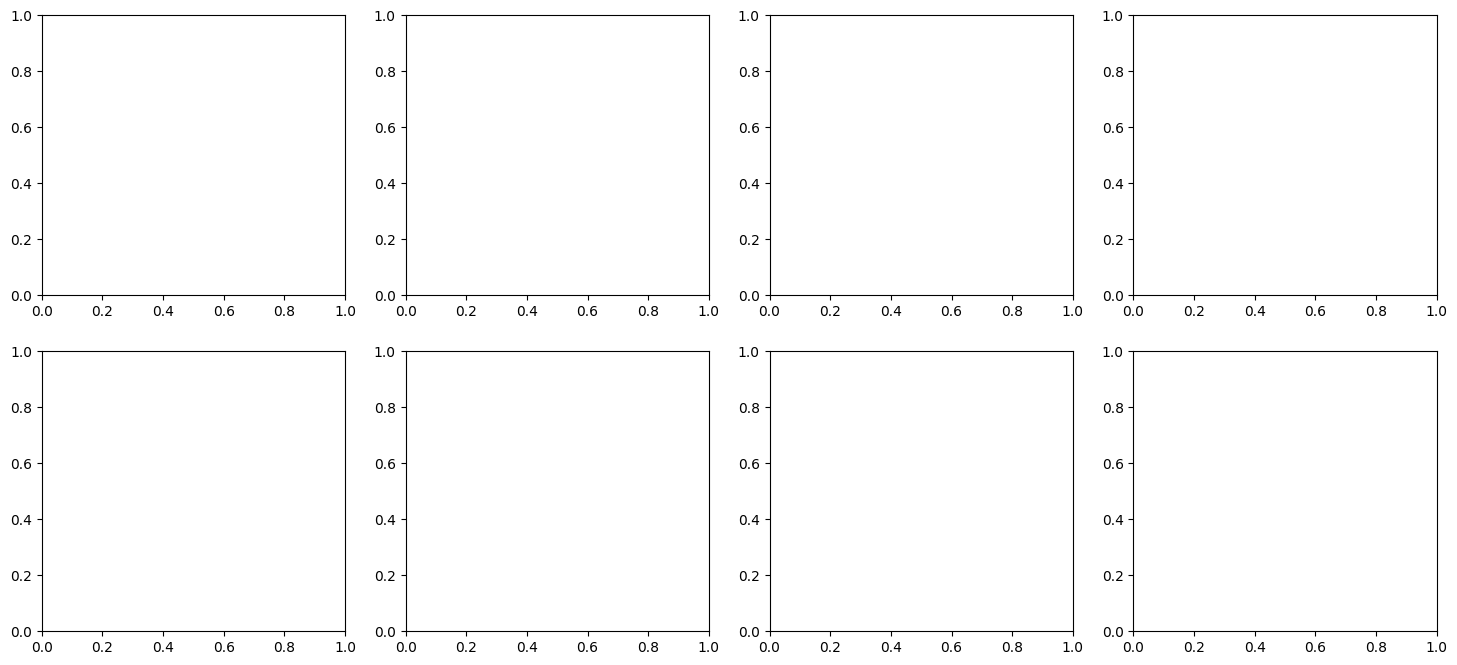

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, feature in zip(axes, mri_features):
    sns.histplot(data[feature].dropna(), bins=30, ax=ax)
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
fig,axes=plt.subplots(2,4,figsize=(18,9))
axes=axes.flatten()

for ax,feature in zip(axes,mri_features):
  sns.boxplot(data=data,x='DX_bl',y=feature,ax=ax)
  ax.set_title(f'{feature} by Baseline Diagnosis')
  ax.set_xlabel('Baseline Diagnosis')
  ax.set_ylabel(feature)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal

for feature in mri_features:
    groups = [
        group[feature].dropna()
        for _, group in data.groupby('DX_bl')
    ]

    stat, p = kruskal(*groups)

    print(f"{feature:20s} | H = {stat:.2f} | p = {p:.4e}")

#<b>Step 4F</b><br>Correlation Analysis

In [ ]:
biomarker_features=biomarker_baseline
all_features=['AGE','PTEDUCAT']+cognitive_features+biomarker_features+mri_features

data[all_features].head()
print('Total features:',len(all_features))

In [ ]:
for feature in all_features:
  data[feature]=pd.to_numeric(data[feature],errors='coerce')

In [ ]:
print(data[all_features].dtypes)

In [ ]:
corr = data[all_features].corr(method='spearman')

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Spearman Correlation of Baseline Features")
plt.tight_layout()
plt.show()